# Step 1 — DATA INVENTORY · burst #21 `bn110920546`
**Status: FINALIZED** — approved by VIKAS. Gates: figure PASS-with-nits, numbers PASS 6/6.

Does every needed file exist, and does each detector's calibration actually cover the times
we analyse? This is the check that caught `bn100130729`'s structural exclusion.

In [1]:
import os, json, glob, hashlib, re, numpy as np
import astropy.io.fits as fits
from astropy.table import Table
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
BURST = "bn110920546"
sha = lambda p: hashlib.sha256(open(p,"rb").read()).hexdigest()
rel = lambda p: os.path.join(ROOT, p)
appr = json.load(open(rel(f"results/sweep106/{BURST}/APPROVALS.json")))
print("repo:", ROOT, "| burst:", BURST)

repo: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks | burst: bn110920546


In [2]:
STEP = "1"

In [3]:
s = appr[STEP]
print(f'step {STEP}: {s["status"]}  by {s["by"]}  {s["utc"]}')
for f in s.get("feedback", []):
    print(f'\n  PI feedback: {f["text"][:400]}')
    if f.get("routed"): print(f'  routed -> {f["routed"][:300]}')

step 1: APPROVED  by VIKAS  2026-08-31T14:47:47Z


## 1. The files

In [4]:
fs = sorted(os.listdir(rel(f"data/{BURST}")))
kinds = {}
for f in fs:
    k = ("TTE" if "_tte_" in f else "CSPEC pha" if f.endswith(".pha") else
         "response rsp2" if ".rsp2" in f else "poshist" if "poshist" in f else "other")
    kinds[k] = kinds.get(k,0)+1
print(f"  {len(fs)} files:", kinds)
print("  LLE files:", len([f for f in fs if 'lle' in f.lower()]), " LAT files:", len([f for f in fs if f.startswith('gll')]))
print("\n  => no LLE, no LAT DATA exist for this trigger. The report must say that,")
print("     never 'not significant' — inclusion is gated on data quality, not detection.")

  22 files: {'CSPEC pha': 7, 'response rsp2': 7, 'poshist': 1, 'TTE': 7}
  LLE files: 0  LAT files: 0

  => no LLE, no LAT DATA exist for this trigger. The report must say that,
     never 'not significant' — inclusion is gated on data quality, not detection.


## 2. Response coverage — the check that can exclude a burst

In [5]:
q = Table.read(rel(f"results/qc/{BURST}_step1_response_coverage.ecsv"), format="ascii.ecsv")
print(q)
print("\n  verdict:", q.meta.get("verdict","")[:150])

DETECTOR                RSP2               N_MATRICES ...  RSP_T1  COVERS_SRC
-------- --------------------------------- ---------- ... -------- ----------
      n0 glg_cspec_n0_bn110920546_v00.rsp2          7 ... 397.8306       True
      n1 glg_cspec_n1_bn110920546_v00.rsp2          7 ... 397.8306       True
      n3 glg_cspec_n3_bn110920546_v00.rsp2          7 ... 397.8306       True
      b0 glg_cspec_b0_bn110920546_v00.rsp2          7 ... 397.8306       True

  verdict: PASS (responses valid; 4/4 approved detectors bracket the stamped window with margin). Carries WARN-1 background/SAA, WARN-2 accepted bkg-gap overrun,


## 3. Detector masks decoded, and the n6 anomaly

n6 is geometrically **closer** than the approved n3, yet absent from both mission masks —
a catalogue decision we inherited, not a geometry error of ours.

In [6]:
s = Table.read(rel("results/grb_sample.ecsv"), format="ascii.ecsv")
r = s[[str(x).strip()==BURST for x in s["TRIGGER_NAME"]]][0]
print("  BCAT mask:", repr(str(r["BCAT_DETECTOR_MASK"])), "-> NaI:", str(r["NAI_DETECTORS"]))
print("  SCAT mask:", repr(str(r["SCAT_DETECTOR_MASK"]).strip()))
pend = json.load(open(rel(f"results/approval/{BURST}_pending.json")))
for c in sorted(pend.get("candidates", pend.get("detectors", [])), key=lambda x: (x["detector"])):
    if c["detector"].startswith("n"):
        print(f'   {c["detector"]}  angle {c["angle_deg"]:6.2f}  in_bcat {c["in_bcat"]}')

  BCAT mask: '11010000000000' -> NaI: n0,n1,n3
  SCAT mask: '11010000000010'
   n0  angle  26.96  in_bcat True
   n1  angle  48.41  in_bcat True
   n3  angle  28.85  in_bcat True
   n6  angle  25.33  in_bcat False
   n7  angle  47.68  in_bcat False


figure sha matches the verified artifact? True
figure verdict : PASS-WITH-NITS (2 nits, zero label-primitive mismatches)
numbers verdict: PASS (6/6 CONFIRMED, 0 not-confirmed, 0 uncheckable)


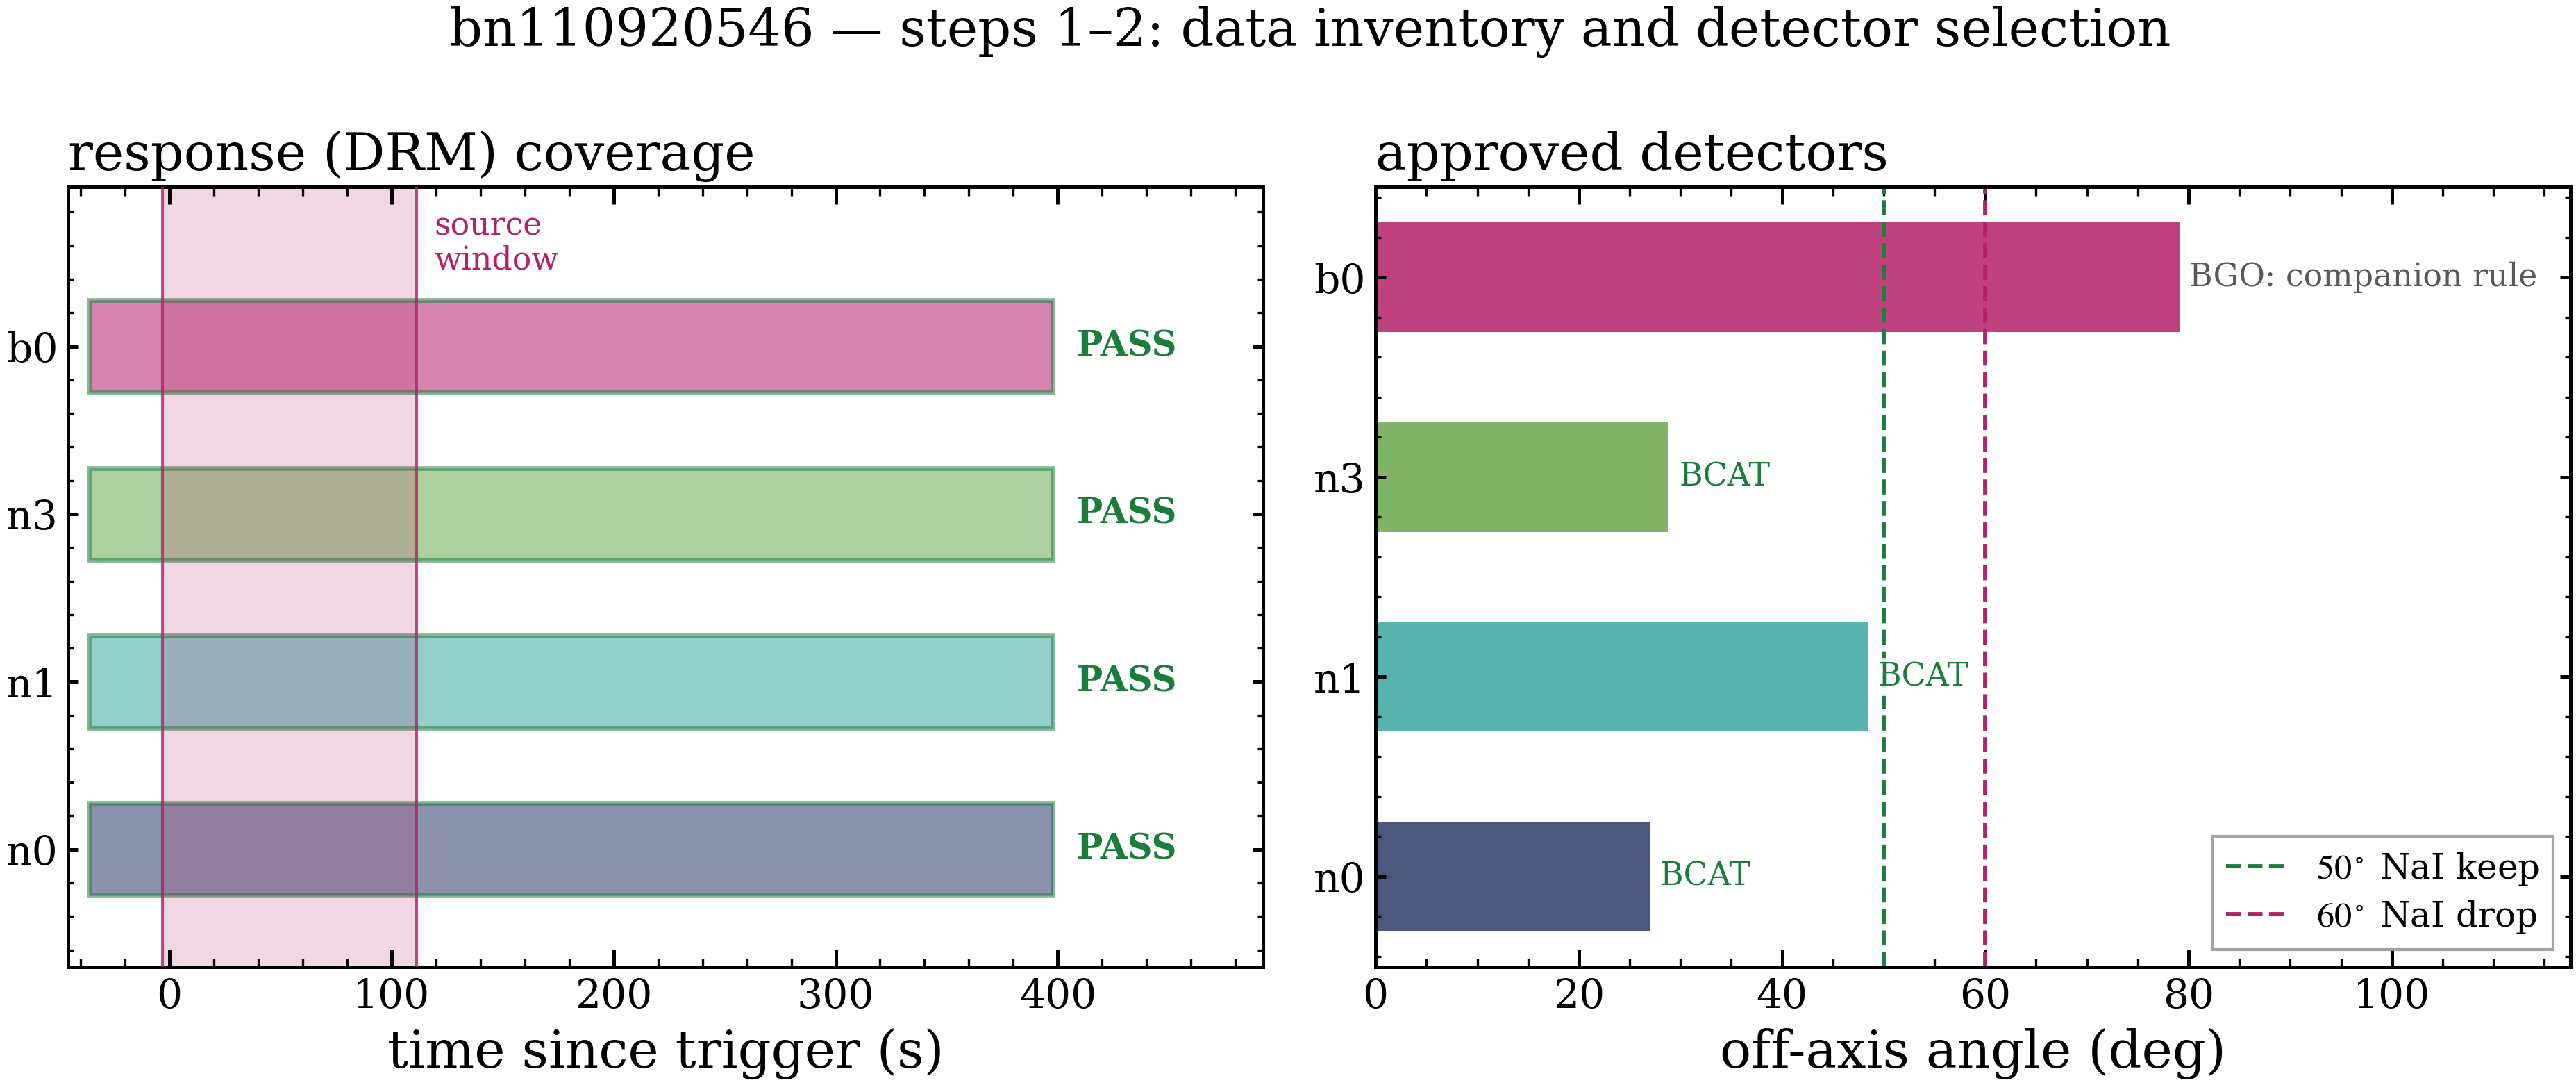

In [7]:
fig = rel(f"results/sweep106/{BURST}/{BURST}_step1_inventory.png")
pin = json.load(open(rel("results/campaign/CAMPAIGN_COMMIT_PIN.json")))["gate_verdicts_hash_bound"]["bn110920546_step1"]
print("figure sha matches the verified artifact?", pin["figure"]["artifact_sha256"] == sha(fig))
print("figure verdict :", pin["figure"]["verdict"])
print("numbers verdict:", pin["numbers"]["verdict"])
from IPython.display import Image, display
display(Image(filename=fig))

## 4. Four standing warnings this step carries
SAA exit at −120.07 s contaminating every pre-burst window · b0's post-background starting
inside the source window (later repaired, step 3) · our window covering ~65% of the catalogue
T90 · n6 excluded though closer.